In [1]:
import pandas as pd
import numpy as np
import sys

def exit_with_error(message):
    print(f"Error: {message}")
    sys.exit(1)

metadata_fname = "metadata/metadata_wide.tsv"
quants_fname = "data/proteins_normalized_wide.tsv"

metadata = pd.read_csv(metadata_fname, sep='\t', na_values=['NA'])
data = pd.read_csv(quants_fname, sep='\t')
data = data.fillna(0)
protein_names = data['protein'].values

print("Metadata shape:", metadata.shape)
print("Data shape:", data.shape)

Metadata shape: (104, 25)
Data shape: (2575, 105)


Data shape: (86, 2575)
Months: [22.42 14.37 14.37 17.36 11.15  5.85 22.42 29.33 22.42 20.48 17.46  5.85
 14.37  8.15 11.15 22.42 30.25 27.   14.37 20.48  5.85  5.85 27.   17.46
 29.33 11.15 20.48  8.15  8.15 17.46 20.58 11.15 27.   22.42 17.46 11.15
 14.37  5.85  8.15 29.33  8.15 22.42 27.   22.42  5.85 11.15  5.85 22.42
 17.46 30.25 20.48  5.85 20.58 17.36  8.15 14.37  8.15 11.15 14.37 22.42
 17.46  8.15 11.15  5.85 22.42 14.37  5.85 20.48 20.48 27.   20.48 17.46
  8.15 29.33 11.15 22.42 20.48 27.   14.37 30.25 14.37 17.36  8.15 11.15
 27.   22.42]
Sex: [0 0 0 1 0 0 1 0 0 1 0 0 1 0 1 1 1 0 1 0 1 1 1 0 0 1 1 1 0 0 0 0 0 0 1 1 0
 1 1 0 1 1 1 0 0 0 1 1 0 1 0 0 0 1 1 1 0 1 0 0 1 1 0 1 0 1 0 1 1 0 1 0 0 0
 0 1 0 0 0 1 1 1 0 1 1 1]


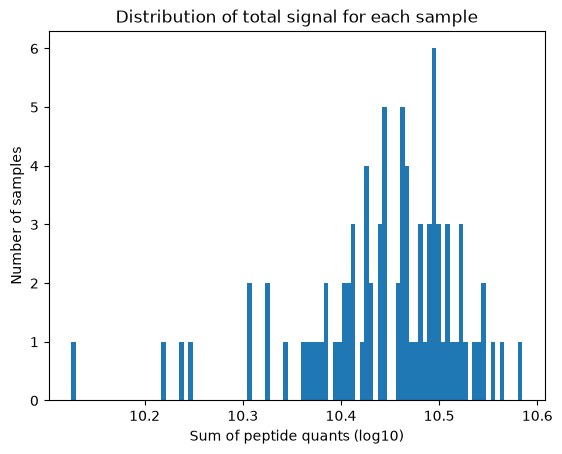

In [2]:
import matplotlib.pyplot as plt

valid_replicates = metadata[metadata['Age_months'].notna()]['replicate'].tolist()

X = []
month = []
sex = []

for idx in valid_replicates:
  for sample in data.columns[:]:
    if idx in sample:
      s_month = metadata[metadata['replicate'] == idx]['Age_months'].values[0]
      s_sex = metadata[metadata['replicate'] == idx]['Sex'].values[0]

      month.append(s_month)
      sex.append(s_sex)
      X.append(data[sample].values)

X = np.array(X)
X = np.power(2, X) # "unlog" X

month = np.array(month)
month = month.astype(float)

sex = np.array(sex)
sex = np.where(sex == "Male", 0, 1) # encode the sex array
sex = sex.astype(int)

print("Data shape:", X.shape)
print("Months:", month)
print("Sex:", sex)

total_signal = np.sum(X, axis=1)
plt.hist(np.log10(total_signal), bins = 100)
plt.title('Distribution of total signal for each sample')
plt.ylabel('Number of samples')
plt.xlabel('Sum of peptide quants (log10)')
plt.show()

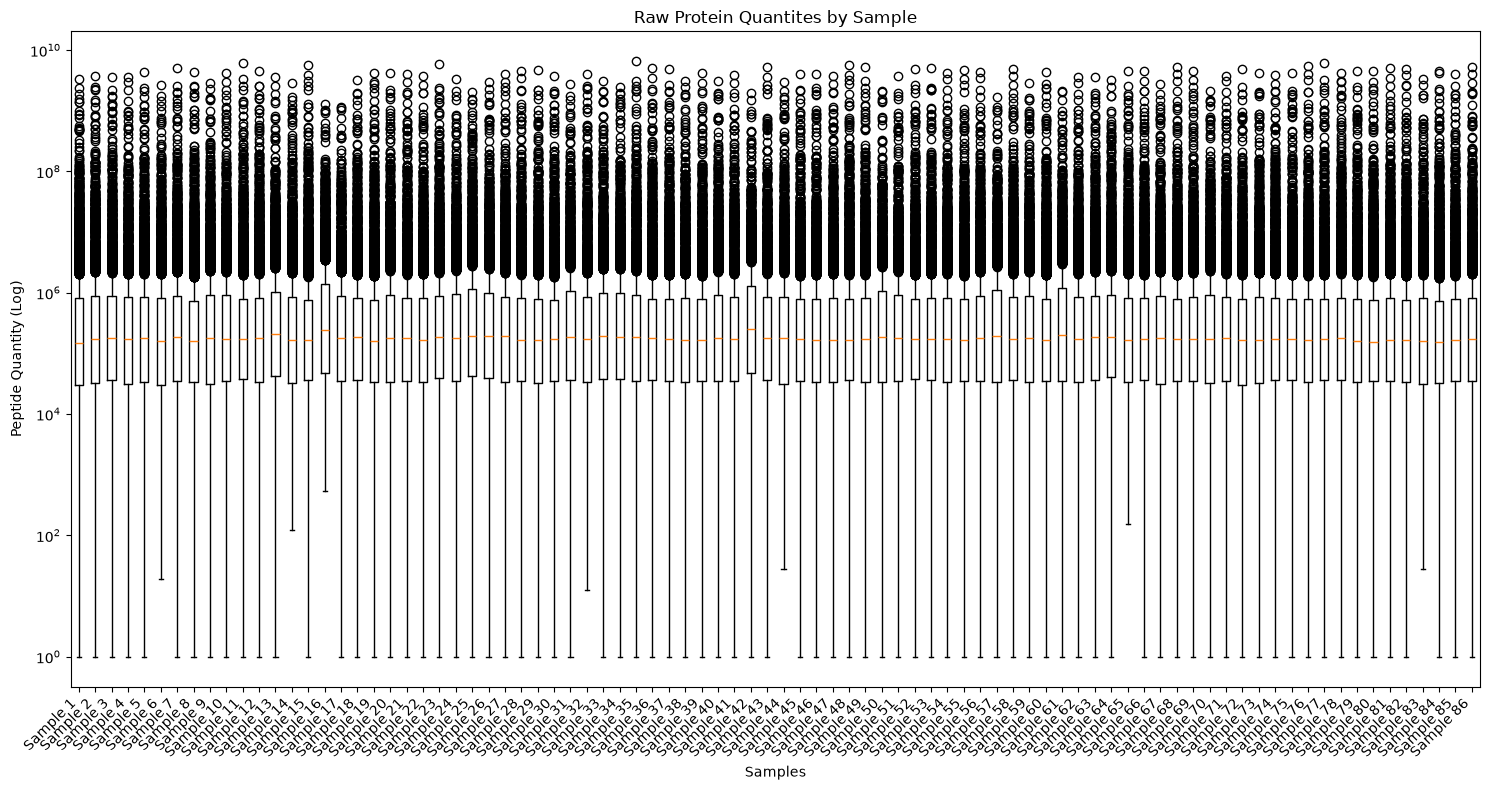

In [3]:
# Create the box plot
plt.figure(figsize=(15, 8))
plt.boxplot(X.T)  # Transpose the data

plt.title('Raw Protein Quantites by Sample')
plt.xlabel('Samples')
plt.ylabel('Peptide Quantity (Log)')
plt.xticks(range(1, X.shape[0] + 1), [f'Sample {i+1}' for i in range(X.shape[0])], rotation=45, ha='right')

# Use log scale for y-axis as peptide quantities often span several orders of magnitude
plt.yscale('log')

plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

In [4]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay


def perform_cross_validation(X, y, protein_names, splits=10, repeats=5, 
                           alpha=0.01, l1_ratio=0.3, random_state=1966):
    """
    Perform cross-validation with ElasticNet regression.
    
    Parameters:
    -----------
    X : array-like
        Feature matrix (already transformed as desired)
    y : array-like
        Target variable (age in months)
    protein_names : array-like
        Names of proteins/features
    splits : int
        Number of CV splits
    repeats : int
        Number of CV repeats
    alpha : float
        ElasticNet alpha parameter
    l1_ratio : float
        ElasticNet l1_ratio parameter
    random_state : int
        Random state for reproducibility
    
    Returns:
    --------
    dict containing:
        - 'predictions': list of predicted values
        - 'true_values': list of true values
        - 'coefficients': average coefficients across folds
        - 'coefficient_counts': number of times each coefficient was non-zero
        - 'protein_names': feature names
        - 'naive_mae': naive MAE baseline
        - 'cv_mae': cross-validation MAE
        - 'r_squared': R² value
        - 'best_fit_params': (slope, intercept) for best fit line
    """
    
    # Calculate naive baseline
    m = sum(y) / len(y)
    naive_mae = sum([np.abs(x - m) for x in y]) / len(y)
    
    # Initialize containers
    pred_i = []
    true_i = []
    all_coeffs = np.zeros(X.shape[1])
    all_coeffs_nonzero = np.zeros(X.shape[1])
    
    # Cross-validation
    skf = RepeatedKFold(n_splits=splits, n_repeats=repeats, random_state=random_state)
    
    for train, test in skf.split(X, y):
        X_train, X_test = X[train], X[test]
        y_train, y_test = y[train], y[test]
        
        # Standardize features
        ss = StandardScaler()
        ss.fit(X_train)
        
        # Fit model
        reg = ElasticNet(random_state=random_state, max_iter=500000, 
                        selection='cyclic', alpha=alpha, l1_ratio=l1_ratio)
        reg.fit(ss.transform(X_train), y_train)
        
        # Accumulate coefficients
        all_coeffs += reg.coef_
        all_coeffs_nonzero += (reg.coef_ != 0).astype(int)
        
        # Store predictions
        pred_i.extend(reg.predict(ss.transform(X_test)))
        true_i.extend(y_test)
    
    # Calculate metrics
    cv_mae = np.mean([np.abs(x - y) for x, y in zip(pred_i, true_i)])
    slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(true_i, pred_i)
    r_squared = r_value ** 2
    
    # Average coefficients across folds
    avg_coeffs = all_coeffs / (splits * repeats)
    
    return {
        'predictions': pred_i,
        'true_values': true_i,
        'coefficients': avg_coeffs,
        'coefficient_counts': all_coeffs_nonzero,
        'protein_names': protein_names,
        'naive_mae': naive_mae,
        'cv_mae': cv_mae,
        'r_squared': r_squared,
        'best_fit_params': (slope, intercept),
        'stats': {
            'slope': slope,
            'intercept': intercept,
            'r_value': r_value,
            'p_value': p_value,
            'std_err': std_err
        }
    }

def plot_scatter(cv_results, save_path=None):
    """
    Create scatter plot of predicted vs true values.
    
    Parameters:
    -----------
    cv_results : dict
        Results from perform_cross_validation function
    save_path : str, optional
        Path to save the plot
    """
    pred_i = cv_results['predictions']
    true_i = cv_results['true_values']
    slope, intercept = cv_results['best_fit_params']
    r_squared = cv_results['r_squared']
    cv_mae = cv_results['cv_mae']
    
    plt.figure(figsize=(8, 6))
    plt.scatter(true_i, pred_i, c='r', s=52, alpha=0.1)
    
    # Best fit line
    xseq = np.linspace(min(true_i), max(true_i), num=2)
    plt.plot(xseq, intercept + slope * xseq, c='r', 
             label=f'Best fit line\n(r²={round(r_squared, 2)}, MAE={round(cv_mae, 2)})')
    
    plt.legend()
    plt.xlabel('True Age (Months)')
    plt.ylabel('Predicted Age (Months)')
    plt.title('Comparison of predicted to true age')
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_error_bars(cv_results, save_path=None):
    """
    Create error bar plot showing mean predictions with standard deviations.
    
    Parameters:
    -----------
    cv_results : dict
        Results from perform_cross_validation function
    save_path : str, optional
        Path to save the plot
    """
    pred_i = np.array(cv_results['predictions'])
    true_i = np.array(cv_results['true_values'])
    slope, intercept = cv_results['best_fit_params']
    r_squared = cv_results['r_squared']
    cv_mae = cv_results['cv_mae']
    
    # Calculate means and errors for each unique true value
    means = []
    true_vals = []
    errors = []
    
    for d in set(true_i):
        mask = (true_i == d)
        p = pred_i[mask]
        means.append(np.mean(p))
        errors.append(np.std(p))
        true_vals.append(d)
    
    plt.figure(figsize=(8, 6))
    plt.errorbar(true_vals, means, errors, linestyle='None', fmt='o', 
                 capsize=5, ecolor='black', color='red', 
                 label="Mean predicted dose (1 std. dev.)")
    
    # Best fit line
    xseq = np.linspace(min(true_i), max(true_i), num=2)
    plt.plot(xseq, intercept + slope * xseq, c='r',
             label=f'Best fit line\n(r²={round(r_squared, 2)}, MAE={round(cv_mae, 2)})')
    
    plt.legend()
    plt.xlabel('True Age (Months)')
    plt.ylabel('Average Predicted Age (Months)')
    plt.title('Comparison of predicted to true age')
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def print_coefficient_summary(cv_results):
    """
    Print summary of coefficient results.
    
    Parameters:
    -----------
    cv_results : dict
        Results from perform_cross_validation function
    """
    coeffs = cv_results['coefficients']
    protein_names = cv_results['protein_names']
    
    print(f"Naive MAE: {cv_results['naive_mae']:.3f}")
    print(f"Cross-validation MAE: {cv_results['cv_mae']:.3f}")
    print(f"R² score: {cv_results['r_squared']:.3f}")
    print()
    print(f"Number of proteins with all-zero coeffs: {sum(coeffs < 1E-12)}")
    print(f"Highest weighted protein: {protein_names[np.argmax(coeffs)]}")
    print()
    print("Proteins with non-zero coefficients:")
    for p in protein_names[coeffs > 1E-12]:
        print(f"  {p}")


def save_predictions(cv_results, filename='regression_cv_fold_test_predictions.txt'):
    """
    Save predictions to file in the same format as original code.
    
    Parameters:
    -----------
    cv_results : dict
        Results from perform_cross_validation function
    filename : str
        Output filename
    """
    pred_i = cv_results['predictions']
    true_i = cv_results['true_values']
    
    np.savetxt(filename, np.column_stack((pred_i, true_i)), 
               delimiter='\t', header='Predicted\tTrue', comments='')
    print(f"Predictions saved to {filename}")

In [5]:
def plot_confusion_matrix(cv_results, save_path=None):
    """
    Create confusion matrix for discretized age predictions.
    
    Parameters:
    -----------
    cv_results : dict
        Results from perform_cross_validation function
    save_path : str, optional
        Path to save the plot
    """
    pred_i = cv_results['predictions']
    true_i = cv_results['true_values']
    
    # Discretize predictions
    y_preds = []
    for x in pred_i:
        if x < 0.5:
            y_preds.append(0)
        else:
            y_preds.append(int((2.5 + x) / 5) * 5)
    
    # Discretize true values
    true_i_discretized = []
    for x in true_i:
        if x < 0.5:
            true_i_discretized.append(0)
        else:
            true_i_discretized.append(int((2.5 + x) / 5) * 5)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    # Flipped the order: y_preds (predicted) first, true_i_discretized (actual) second
    ConfusionMatrixDisplay.from_predictions(y_preds, true_i_discretized, 
                                          ax=ax, colorbar=False, cmap='viridis',
                                          text_kw={'fontsize': 20})
    ax.tick_params(axis='both', which='major', labelsize=24)
    ax.set_xlabel("Chronological Age", fontsize=20)  # Now x-axis shows chronological age
    ax.set_ylabel("Predicted Age", fontsize=20)      # Now y-axis shows predicted age
    ax.invert_yaxis()  # Reverse y-axis so lowest values are at bottom
    
    if save_path:
        plt.savefig(save_path+".pdf", dpi=300, bbox_inches='tight')
        plt.savefig(save_path+".svg", dpi=300, bbox_inches='tight')
        plt.savefig(save_path+".png", dpi=300, bbox_inches='tight')
        
    plt.show()

In [6]:
def plot_boxplot_with_points(cv_results, save_path=None, random_state=1966, 
                            x_range=None, y_range=None, tick_interval=None):
    """
    Create box plot with individual prediction points and best fit line.
    
    Parameters:
    -----------
    cv_results : dict
        Results from perform_cross_validation function
    save_path : str, optional
        Path to save the plot
    random_state : int
        Random state for jitter reproducibility
    x_range : tuple, optional
        (min, max) for x-axis. If None, automatically determined from data
    y_range : tuple, optional
        (min, max) for y-axis. If None, automatically determined from data
    tick_interval : float, optional
        Interval between tick marks. If None, automatically determined
    """
    pred_i = np.array(cv_results['predictions'])
    true_i = np.array(cv_results['true_values'])
    slope, intercept = cv_results['best_fit_params']
    r_squared = cv_results['r_squared']
    cv_mae = cv_results['cv_mae']
    
    # Determine reasonable axis ranges if not provided
    if x_range is None:
        # For x-axis, use only true values
        data_min = true_i.min()
        data_max = true_i.max()
        data_range = data_max - data_min
        # Add 10% padding on each side
        padding = data_range * 0.1
        x_min = data_min - padding
        x_max = data_max + padding
        # Round to nice numbers
        x_min = np.floor(x_min)
        x_max = np.ceil(x_max)
        x_range = (x_min, x_max)
    
    if y_range is None:
        # For y-axis, use only predicted values
        data_min = pred_i.min()
        data_max = pred_i.max()
        data_range = data_max - data_min
        padding = data_range * 0.1
        y_min = data_min - padding
        y_max = data_max + padding
        # Round to nice numbers
        y_min = np.floor(y_min)
        y_max = np.ceil(y_max)
        y_range = (y_min, y_max)
    
    # Determine reasonable tick intervals independently for each axis
    if tick_interval is None:
        # Calculate x-axis tick interval
        x_axis_range = x_range[1] - x_range[0]
        x_tick_interval = x_axis_range / 6  # Aim for about 7 ticks
        
        # Round to a nice number for x-axis
        magnitude = 10 ** np.floor(np.log10(x_tick_interval))
        normalized = x_tick_interval / magnitude
        
        if normalized <= 1:
            x_tick_interval = magnitude
        elif normalized <= 2:
            x_tick_interval = 2 * magnitude
        elif normalized <= 5:
            x_tick_interval = 5 * magnitude
        else:
            x_tick_interval = 10 * magnitude
        
        # Calculate y-axis tick interval
        y_axis_range = y_range[1] - y_range[0]
        y_tick_interval = y_axis_range / 6  # Aim for about 7 ticks
        
        # Round to a nice number for y-axis
        magnitude = 10 ** np.floor(np.log10(y_tick_interval))
        normalized = y_tick_interval / magnitude
        
        if normalized <= 1:
            y_tick_interval = magnitude
        elif normalized <= 2:
            y_tick_interval = 2 * magnitude
        elif normalized <= 5:
            y_tick_interval = 5 * magnitude
        else:
            y_tick_interval = 10 * magnitude
    else:
        # If tick_interval is provided, use it for both axes
        x_tick_interval = tick_interval
        y_tick_interval = tick_interval
    
    # Create figure and axis explicitly
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Round true values to nearest 0.1 for grouping
    true_i_rounded = np.round(true_i, 1)
    
    # Get unique rounded true values and group predictions
    unique_true_vals = sorted(set(true_i_rounded))
    prediction_groups = []
    bin_positions = []
    
    for true_val in unique_true_vals:
        mask = (true_i_rounded == true_val)
        predictions_for_val = pred_i[mask]
        prediction_groups.append(predictions_for_val)
        bin_positions.append(true_val)
    
    # Create box plots using the axis object
    box_plot = ax.boxplot(prediction_groups, positions=bin_positions, widths=1,
                          patch_artist=False, showfliers=False, 
                          manage_ticks=False)  # This prevents boxplot from managing ticks
    
    # Add individual prediction points with jitter using viridis color scale
    np.random.seed(random_state)
    
    # Create colormap for viridis
    cmap = plt.cm.viridis
    
    # Normalize the true values for color mapping
    norm = plt.Normalize(vmin=min(true_i), vmax=max(true_i))
    
    for i, true_val in enumerate(bin_positions):
        mask = (true_i_rounded == true_val)
        predictions_for_val = pred_i[mask]
        true_vals_for_group = true_i[mask]  # Get original true values for coloring
        jitter = np.random.normal(0, 0.02, len(predictions_for_val))
        x_coords = [true_val + j for j in jitter]
        
        # Color points based on their true values using viridis
        colors = cmap(norm(true_vals_for_group))
        ax.scatter(x_coords, predictions_for_val, alpha=0.6, s=20, 
                   c=colors, zorder=3)
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Chronological Age (Months)', fontsize=22)
    cbar.ax.tick_params(labelsize=20)
    
    # Add best fit line - extend to full range
    xseq = np.linspace(x_range[0], x_range[1], num=100)
    ax.plot(xseq, intercept + slope * xseq, c='darkred', linewidth=2,
            label=f'Best fit line (r²={r_squared:.2f}, MAE={cv_mae:.2f})',
            zorder=4)
    
    # Add perfect prediction line - extend to full range
    line_min = max(x_range[0], y_range[0])
    line_max = min(x_range[1], y_range[1])
    ax.plot([line_min, line_max], [line_min, line_max], 'k--', alpha=0.5, linewidth=1, 
            label='Perfect prediction', zorder=2)
    
    # FORCE the axis limits and ticks
    ax.set_xlim(x_range[0], x_range[1])
    ax.set_ylim(y_range[0], y_range[1])
    
    # Set specific tick positions
    x_ticks = np.arange(x_range[0], x_range[1] + x_tick_interval/2, x_tick_interval)
    y_ticks = np.arange(y_range[0], y_range[1] + y_tick_interval/2, y_tick_interval)
    
    # Clear any existing ticks first
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Now set our desired ticks
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)
    
    # Force matplotlib to use our ticks by setting them as both major and minor
    ax.xaxis.set_major_locator(plt.FixedLocator(x_ticks))
    ax.yaxis.set_major_locator(plt.FixedLocator(y_ticks))
    
    # Labels and formatting
    ax.set_xlabel('Chronological Age (Months)', fontsize=24)
    ax.set_ylabel('Predicted Age (Months)', fontsize=24)
    ax.legend(loc='upper left', fontsize=15)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=20)
    
    # Force the limits again to ensure they stick
    ax.set_xlim(x_range[0], x_range[1])
    ax.set_ylim(y_range[0], y_range[1])
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path+".pdf", dpi=300, bbox_inches='tight')
        plt.savefig(save_path+".svg", dpi=300, bbox_inches='tight')
        plt.savefig(save_path+".png", dpi=300, bbox_inches='tight')
        
    plt.show()

In [7]:
labeled_X = np.log10(X)
y = month
# add sex as a feature
sex_feature = sex.reshape(-1, 1)
labeled_X = np.hstack([labeled_X, sex_feature])
tmp_protein_names = np.append(protein_names, "sex")


results = perform_cross_validation(labeled_X, y, tmp_protein_names)

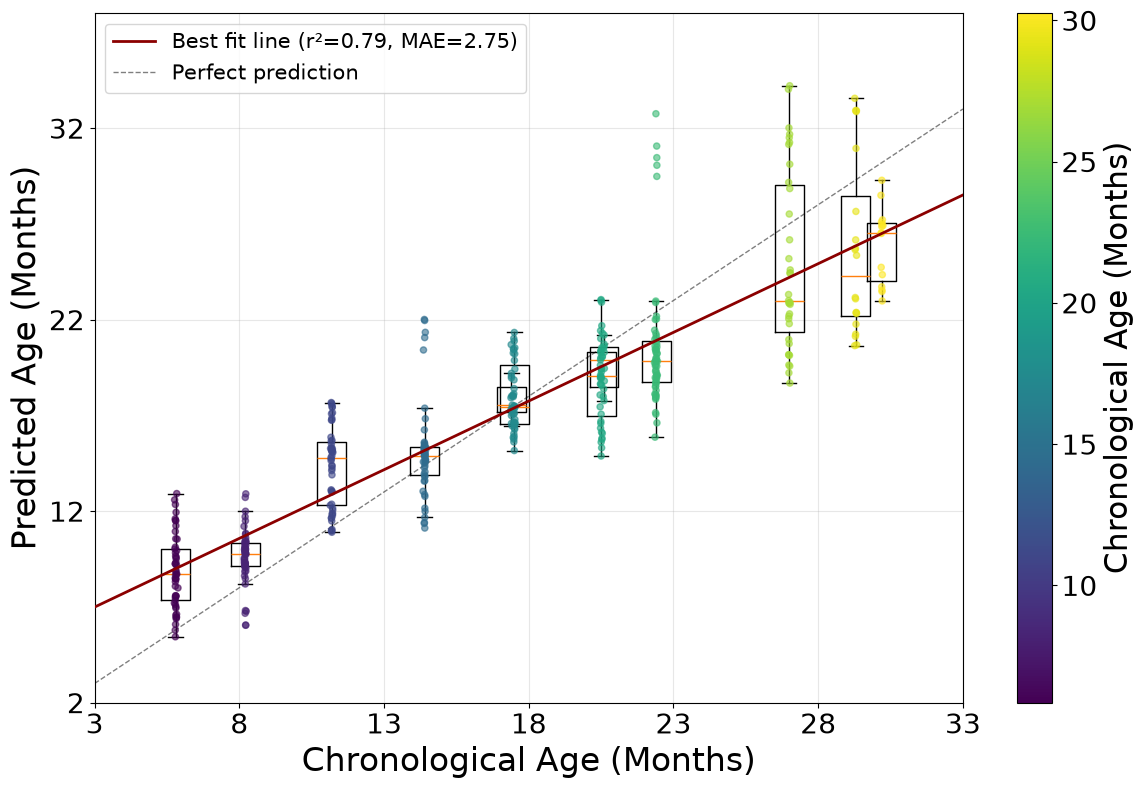

In [8]:
plot_boxplot_with_points(results, save_path='results/protein-age-regression-scatter-boxplot')

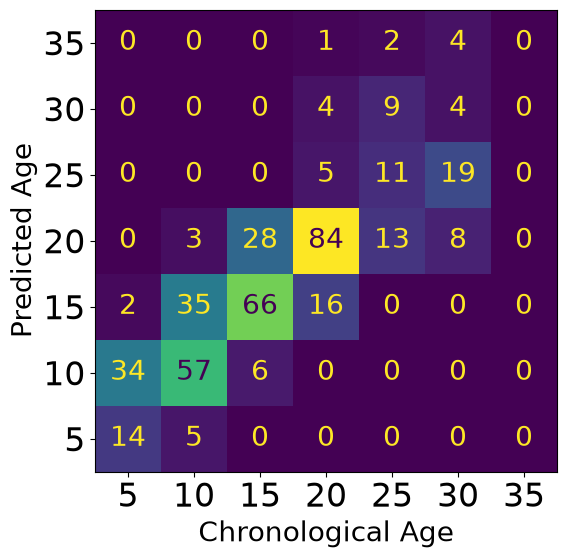

In [9]:
plot_confusion_matrix(results, save_path='results/protein-age-regression-confusion-matrix')

In [10]:
df = pd.DataFrame({
    'feature': results['protein_names'],
    'coefficient': results['coefficients'],
    'nonzero_count': results['coefficient_counts']
})
df = df.sort_values('coefficient', ascending=False)
df.to_csv('results/protein-age-regression-feature-importances.csv', index=False)

## Final Model (All Data)
Train a final ElasticNet model using all available data with the same method and hyperparameters used in the cross-validation folds above. Save the per-protein coefficients to a CSV report.

In [11]:
def train_final_model(X, y, protein_names, alpha=0.01, l1_ratio=0.3, random_state=1966):
    """
    Train a final ElasticNet model on all data using the same method
    and hyperparameters as the cross-validation folds.
    
    Parameters:
    -----------
    X : array-like
        Feature matrix
    y : array-like
        Target variable (age in months)
    protein_names : array-like
        Names of proteins/features
    alpha : float
        ElasticNet alpha parameter
    l1_ratio : float
        ElasticNet l1_ratio parameter
    random_state : int
        Random state for reproducibility
    
    Returns:
    --------
    dict containing:
        - 'model': fitted ElasticNet model
        - 'scaler': fitted StandardScaler
        - 'coefficients': model coefficients
        - 'intercept': model intercept
        - 'protein_names': feature names
    """
    # Standardize features (same as in CV folds)
    ss = StandardScaler()
    ss.fit(X)
    X_scaled = ss.transform(X)
    
    # Fit ElasticNet with same hyperparameters as CV
    reg = ElasticNet(random_state=random_state, max_iter=500000,
                     selection='cyclic', alpha=alpha, l1_ratio=l1_ratio)
    reg.fit(X_scaled, y)
    
    return {
        'model': reg,
        'scaler': ss,
        'coefficients': reg.coef_,
        'intercept': reg.intercept_,
        'protein_names': protein_names,
    }

# Train final model on all data
final_model = train_final_model(labeled_X, y, tmp_protein_names)

# Build report DataFrame
final_df = pd.DataFrame({
    'feature': final_model['protein_names'],
    'coefficient': final_model['coefficients'],
})

# Sort by absolute coefficient value (descending) so all non-zero features appear at the top
final_df = final_df.sort_values('coefficient', key=lambda x: x.abs(), ascending=False)

# Save to CSV
output_path = 'results/protein-age-regression-final-model-coefficients.csv'
final_df.to_csv(output_path, index=False)

# Summary
n_nonzero = (final_df['coefficient'].abs() > 1e-12).sum()
print(f"Final model intercept: {final_model['intercept']:.4f}")
print(f"Total features: {len(final_df)}")
print(f"Features with non-zero coefficients: {n_nonzero}")
print(f"\nCoefficients saved to {output_path}")
print(f"\nTop features by coefficient magnitude:")
print(final_df.head(10).to_string(index=False))

Final model intercept: 16.7513
Total features: 2576
Features with non-zero coefficients: 277

Coefficients saved to results/protein-age-regression-final-model-coefficients.csv

Top features by coefficient magnitude:
                                                        feature  coefficient
                                           sp|Q7TQ62|PODN_MOUSE     0.383254
                                          sp|Q91W90|TXND5_MOUSE     0.380033
tr|A0A075B5N2|A0A075B5N2_MOUSE / tr|A0A140T8P2|A0A140T8P2_MOUSE     0.372645
                                          sp|P01632|KV1A1_MOUSE    -0.366398
                                           sp|O55189|AMBN_MOUSE     0.358782
                                          sp|D3Z7H8|CILP2_MOUSE    -0.332155
                                           sp|Q9WTP6|KAD2_MOUSE    -0.310896
                                          sp|O08807|PRDX4_MOUSE     0.301852
                                          sp|Q8K0J2|B3GN7_MOUSE    -0.293948
              